# 🧠 MNIST Neural Network with PyTorch
A complete implementation covering data loading, model building, training, evaluation, and visualization.

## 1. Imports & Setup

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import time

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'PyTorch version: {torch.__version__}')

Using device: cpu
PyTorch version: 2.9.1+cpu


## 2. Hyperparameters

In [3]:
# Hyperparameters
INPUT_SIZE    = 784       # 28x28 pixels
HIDDEN_SIZE_1 = 512
HIDDEN_SIZE_2 = 256
HIDDEN_SIZE_3 = 128
NUM_CLASSES   = 10
NUM_EPOCHS    = 10
BATCH_SIZE    = 64
LEARNING_RATE = 0.001
DROPOUT_RATE  = 0.3

print('Hyperparameters:')
print(f'  Input Size     : {INPUT_SIZE}')
print(f'  Hidden Layers  : {HIDDEN_SIZE_1} -> {HIDDEN_SIZE_2} -> {HIDDEN_SIZE_3}')
print(f'  Num Classes    : {NUM_CLASSES}')
print(f'  Epochs         : {NUM_EPOCHS}')
print(f'  Batch Size     : {BATCH_SIZE}')
print(f'  Learning Rate  : {LEARNING_RATE}')
print(f'  Dropout Rate   : {DROPOUT_RATE}')

Hyperparameters:
  Input Size     : 784
  Hidden Layers  : 512 -> 256 -> 128
  Num Classes    : 10
  Epochs         : 10
  Batch Size     : 64
  Learning Rate  : 0.001
  Dropout Rate   : 0.3


## 3. Data Loading & Preprocessing

In [5]:
# Transforms: normalize to mean=0.1307, std=0.3081 (MNIST dataset statistics)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Download and load datasets
train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, transform=transform, download=True)

test_dataset = torchvision.datasets.MNIST(
    root='./data', train=False, transform=transform, download=True)

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'Training samples  : {len(train_dataset):,}')
print(f'Test samples      : {len(test_dataset):,}')
print(f'Training batches  : {len(train_loader)}')
print(f'Test batches      : {len(test_loader)}')

Training samples  : 60,000
Test samples      : 10,000
Training batches  : 938
Test batches      : 157


## 4. Visualize Sample Data

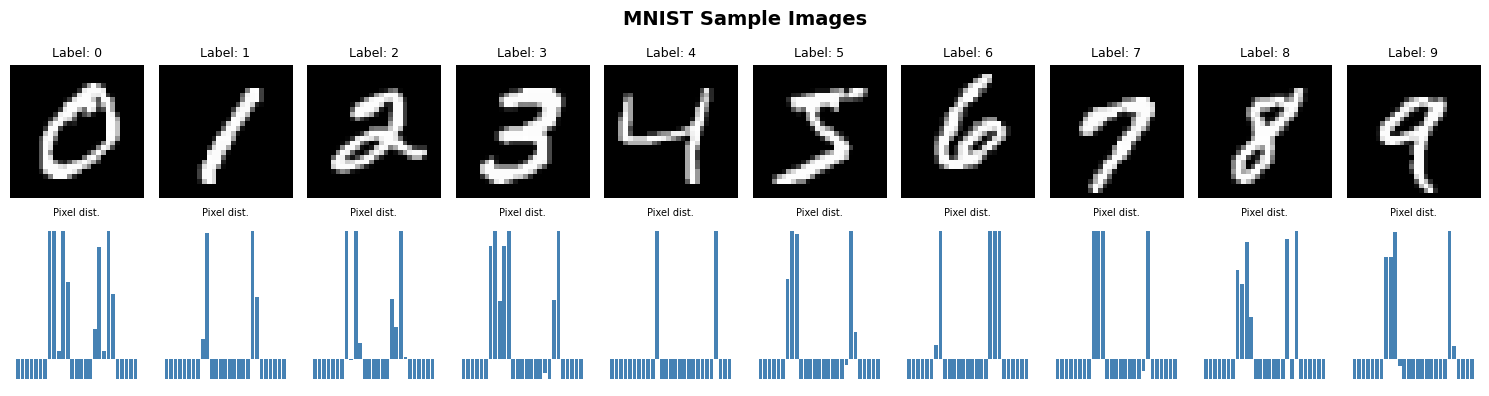

In [6]:
def show_samples(dataset, n=10):
    fig, axes = plt.subplots(2, n, figsize=(15, 4))
    fig.suptitle('MNIST Sample Images', fontsize=14, fontweight='bold')
    
    # Show one sample per class (digits 0-9)
    class_shown = {}
    samples = []
    for img, label in dataset:
        if label not in class_shown:
            class_shown[label] = img
            samples.append((img, label))
        if len(samples) == n:
            break
    samples.sort(key=lambda x: x[1])

    for i, (img, label) in enumerate(samples):
        # Original
        axes[0, i].imshow(img.squeeze(), cmap='gray')
        axes[0, i].set_title(f'Label: {label}', fontsize=9)
        axes[0, i].axis('off')
        # Flattened view
        axes[1, i].bar(range(0, 784, 30), img.view(-1)[::30].numpy(), color='steelblue', width=25)
        axes[1, i].set_title('Pixel dist.', fontsize=7)
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()

show_samples(train_dataset)

## 5. Model Architecture

In [8]:
class MNISTNet(nn.Module):
    """
    Fully Connected Neural Network for MNIST classification.
    Architecture: 784 -> 512 -> 256 -> 128 -> 10
    Features: BatchNorm, Dropout, ReLU activations
    """
    def __init__(self, input_size, hidden1, hidden2, hidden3, num_classes, dropout_rate):
        super(MNISTNet, self).__init__()
        
        self.network = nn.Sequential(
            # Layer 1
            nn.Linear(input_size, hidden1),
            nn.BatchNorm1d(hidden1),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            # Layer 2
            nn.Linear(hidden1, hidden2),
            nn.BatchNorm1d(hidden2),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            # Layer 3
            nn.Linear(hidden2, hidden3),
            nn.BatchNorm1d(hidden3),
            nn.ReLU(),
            nn.Dropout(dropout_rate / 2),
            
            # Output Layer
            nn.Linear(hidden3, num_classes)
        )
    
    def forward(self, x):
        x = x.view(x.size(0), -1)   # Flatten: (B, 1, 28, 28) -> (B, 784)
        return self.network(x)


# Instantiate model
model = MNISTNet(
    INPUT_SIZE, HIDDEN_SIZE_1, HIDDEN_SIZE_2,
    HIDDEN_SIZE_3, NUM_CLASSES, DROPOUT_RATE
).to(device)

print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}')
print(f'Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

MNISTNet(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.15, inplace=False)
    (12): Linear(in_features=128, out_features=10, bias=True)
  )
)

Total parameters: 569,226
Trainable params: 569,226


## 6. Loss Function & Optimizer

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

# Learning rate scheduler: reduce LR by 0.5 every 3 epochs
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

print(f'Loss      : {criterion}')
print(f'Optimizer : {optimizer.__class__.__name__}  (lr={LEARNING_RATE}, weight_decay=1e-4)')
print(f'Scheduler : StepLR (step=3, gamma=0.5)')

Loss      : CrossEntropyLoss()
Optimizer : Adam  (lr=0.001, weight_decay=1e-4)
Scheduler : StepLR (step=3, gamma=0.5)


## 7. Training & Validation Loop

In [10]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total   += labels.size(0)
    
    return total_loss / total, 100. * correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)
            
            total_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total   += labels.size(0)
    
    return total_loss / total, 100. * correct / total


# ── Training Loop ──────────────────────────────────────────────────────────
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}
best_val_acc = 0.0
best_model_state = None

print(f'{"Epoch":>6}  {"Train Loss":>10}  {"Train Acc":>10}  {"Val Loss":>9}  {"Val Acc":>8}  {"LR":>8}  {"Time":>6}')
print('-' * 70)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss,   val_acc   = evaluate(model, test_loader, criterion, device)
    scheduler.step()
    
    current_lr = scheduler.get_last_lr()[0]
    elapsed    = time.time() - t0
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['lr'].append(current_lr)
    
    marker = ' ✓ best' if val_acc > best_val_acc else ''
    if val_acc > best_val_acc:
        best_val_acc    = val_acc
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
    
    print(f'{epoch:>6}  {train_loss:>10.4f}  {train_acc:>9.2f}%  {val_loss:>9.4f}  {val_acc:>7.2f}%  {current_lr:>8.6f}  {elapsed:>5.1f}s{marker}')

print('-' * 70)
print(f'Best Validation Accuracy: {best_val_acc:.2f}%')

 Epoch  Train Loss   Train Acc   Val Loss   Val Acc        LR    Time
----------------------------------------------------------------------
     1      0.2793      92.14%     0.1097    96.74%  0.001000   26.3s ✓ best
     2      0.1412      95.72%     0.0790    97.33%  0.001000   25.7s ✓ best
     3      0.1145      96.43%     0.0701    97.87%  0.000500   24.0s ✓ best
     4      0.0827      97.43%     0.0545    98.26%  0.000500   24.1s ✓ best
     5      0.0706      97.82%     0.0546    98.22%  0.000500   28.1s
     6      0.0663      97.96%     0.0530    98.27%  0.000250   27.2s ✓ best
     7      0.0519      98.38%     0.0443    98.54%  0.000250   26.2s ✓ best
     8      0.0434      98.61%     0.0449    98.52%  0.000250   27.1s
     9      0.0415      98.64%     0.0442    98.59%  0.000125   26.5s ✓ best
    10      0.0364      98.82%     0.0435    98.73%  0.000125   26.7s ✓ best
----------------------------------------------------------------------
Best Validation Accuracy: 98.73%

## 8. Training Curves

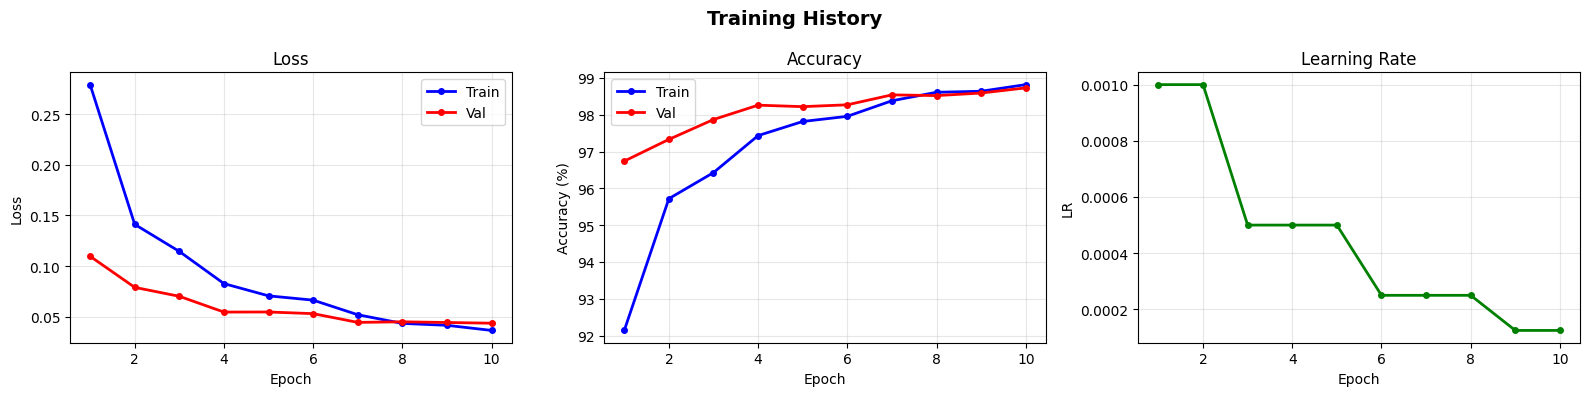

In [11]:
epochs = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Training History', fontsize=14, fontweight='bold')

# Loss
axes[0].plot(epochs, history['train_loss'], 'b-o', label='Train', linewidth=2, markersize=4)
axes[0].plot(epochs, history['val_loss'],   'r-o', label='Val',   linewidth=2, markersize=4)
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs, history['train_acc'], 'b-o', label='Train', linewidth=2, markersize=4)
axes[1].plot(epochs, history['val_acc'],   'r-o', label='Val',   linewidth=2, markersize=4)
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# Learning Rate
axes[2].plot(epochs, history['lr'], 'g-o', linewidth=2, markersize=4)
axes[2].set_title('Learning Rate'); axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('LR')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Evaluate Best Model

In [12]:
# Load best weights
model.load_state_dict(best_model_state)

# Collect all predictions
model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs   = F.softmax(outputs, dim=1)
        _, preds = outputs.max(1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

accuracy = (all_preds == all_labels).mean() * 100
print(f'Test Accuracy: {accuracy:.2f}%')
print()
print('Classification Report:')
print(classification_report(all_labels, all_preds, target_names=[str(i) for i in range(10)]))

Test Accuracy: 98.73%

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.98      0.99      0.99      1010
           4       0.99      0.98      0.99       982
           5       0.99      0.98      0.99       892
           6       0.99      0.99      0.99       958
           7       0.98      0.99      0.98      1028
           8       0.99      0.98      0.99       974
           9       0.98      0.99      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



## 10. Confusion Matrix

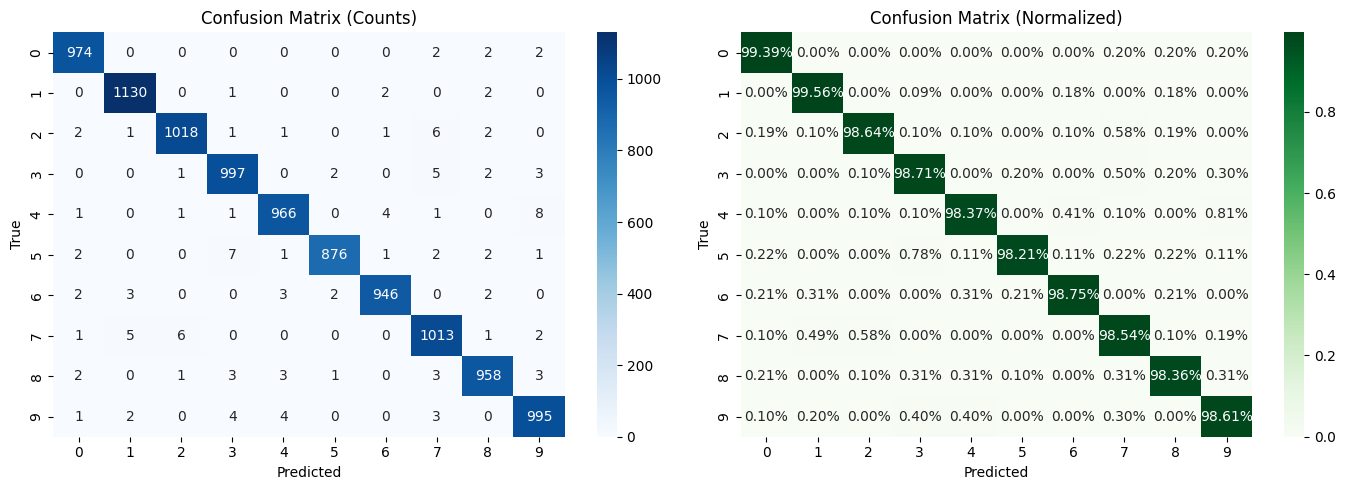

In [13]:
cm = confusion_matrix(all_labels, all_preds)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=range(10), yticklabels=range(10))
axes[0].set_title('Confusion Matrix (Counts)')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

# Normalized
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens', ax=axes[1],
            xticklabels=range(10), yticklabels=range(10))
axes[1].set_title('Confusion Matrix (Normalized)')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()

## 11. Visualize Predictions

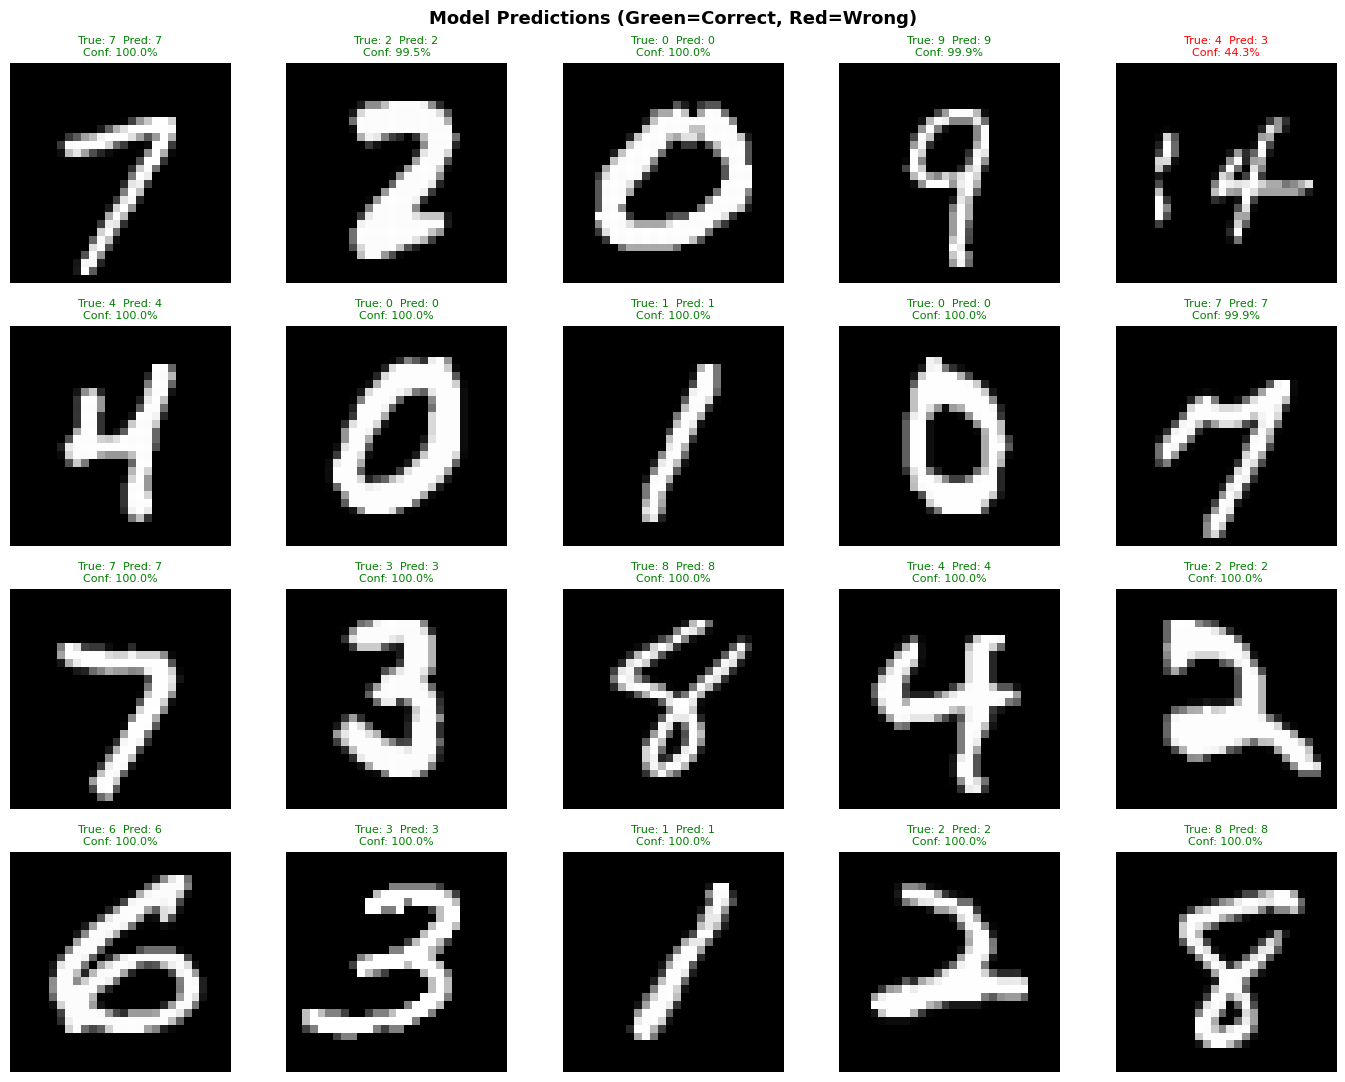

In [14]:
def show_predictions(dataset, model, device, n=20):
    model.eval()
    images_shown, labels_shown, preds_shown, probs_shown = [], [], [], []
    
    loader = DataLoader(dataset, batch_size=n, shuffle=True)
    images, labels = next(iter(loader))
    
    with torch.no_grad():
        outputs = model(images.to(device))
        probs   = F.softmax(outputs, dim=1).cpu()
        _, preds = outputs.max(1)
    
    fig, axes = plt.subplots(4, 5, figsize=(14, 11))
    fig.suptitle('Model Predictions (Green=Correct, Red=Wrong)', fontsize=13, fontweight='bold')
    
    for i, ax in enumerate(axes.flat):
        img   = images[i].squeeze().numpy()
        true  = labels[i].item()
        pred  = preds[i].item()
        conf  = probs[i][pred].item() * 100
        color = 'green' if pred == true else 'red'
        
        ax.imshow(img, cmap='gray')
        ax.set_title(f'True: {true}  Pred: {pred}\nConf: {conf:.1f}%',
                     color=color, fontsize=8)
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

show_predictions(test_dataset, model, device)

## 12. Visualize Misclassified Examples

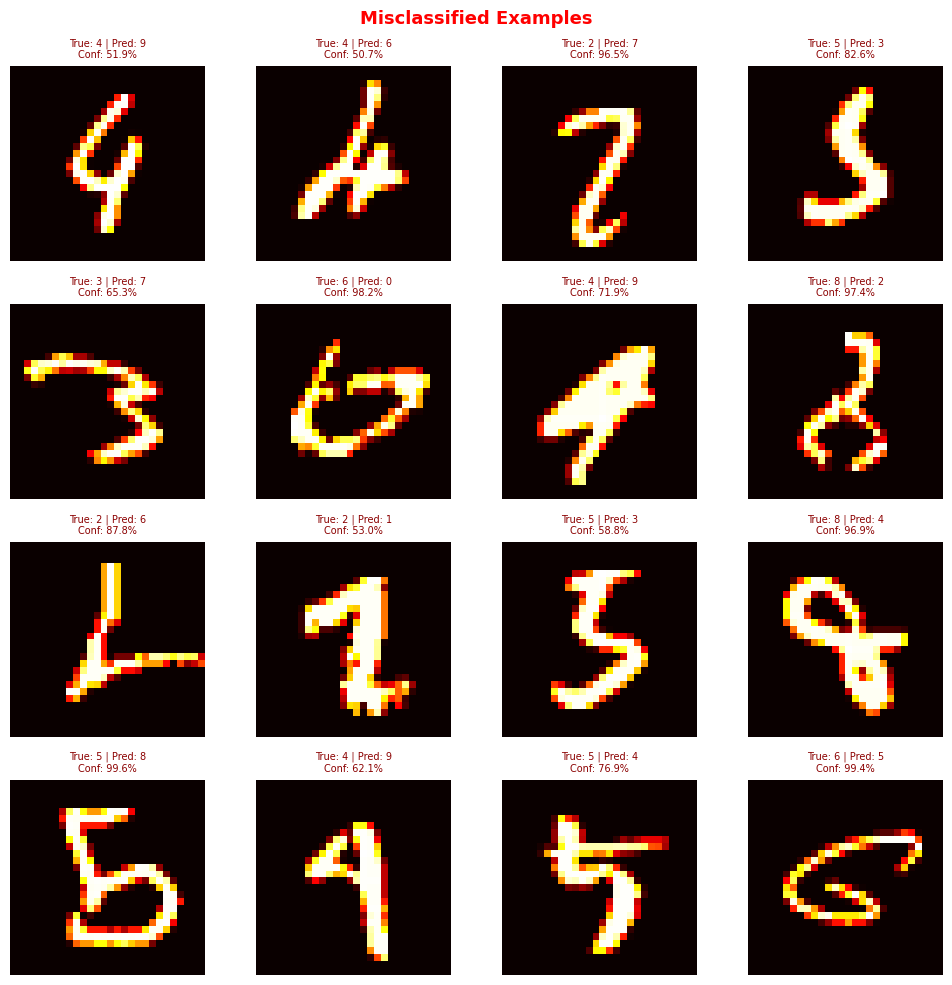

Total misclassified on test set: 127 / 10000


In [15]:
def show_misclassified(dataset, model, device, n=16):
    model.eval()
    wrong_imgs, wrong_true, wrong_pred, wrong_conf = [], [], [], []
    
    loader = DataLoader(dataset, batch_size=256, shuffle=False)
    
    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images.to(device))
            probs   = F.softmax(outputs, dim=1).cpu()
            _, preds = outputs.max(1)
            preds = preds.cpu()
            
            mask = (preds != labels)
            wrong_imgs.append(images[mask])
            wrong_true.append(labels[mask])
            wrong_pred.append(preds[mask])
            wrong_conf.append(probs[mask].max(1).values)
            
            if sum(len(x) for x in wrong_imgs) >= n:
                break
    
    wrong_imgs = torch.cat(wrong_imgs)[:n]
    wrong_true = torch.cat(wrong_true)[:n]
    wrong_pred = torch.cat(wrong_pred)[:n]
    wrong_conf = torch.cat(wrong_conf)[:n]
    
    fig, axes = plt.subplots(4, 4, figsize=(10, 10))
    fig.suptitle('Misclassified Examples', fontsize=13, fontweight='bold', color='red')
    
    for i, ax in enumerate(axes.flat):
        ax.imshow(wrong_imgs[i].squeeze().numpy(), cmap='hot')
        ax.set_title(f'True: {wrong_true[i].item()} | Pred: {wrong_pred[i].item()}\n'
                     f'Conf: {wrong_conf[i].item()*100:.1f}%', fontsize=7, color='darkred')
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()
    print(f'Total misclassified on test set: {(all_preds != all_labels).sum()} / {len(all_labels)}')

show_misclassified(test_dataset, model, device)

## 13. Confidence Distribution

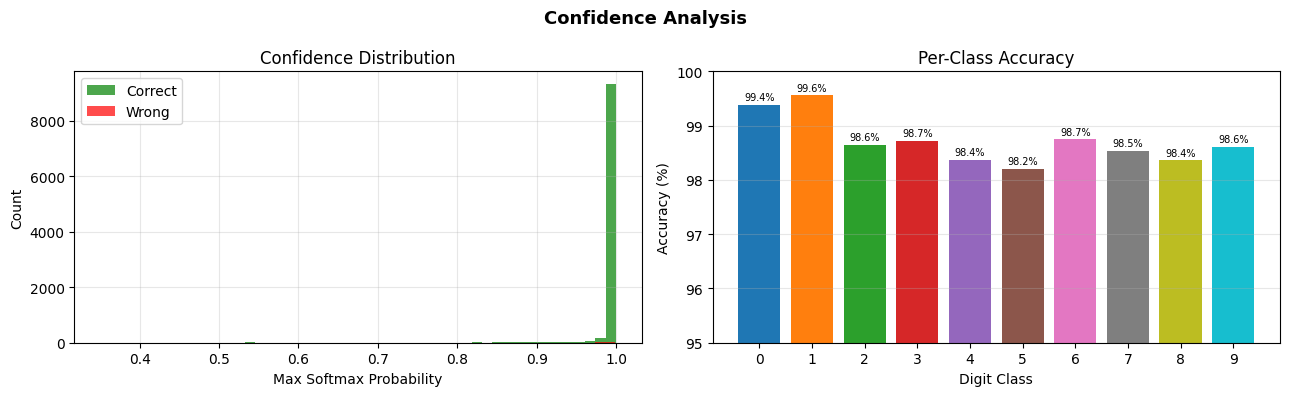

In [19]:
max_probs    = all_probs.max(axis=1)
correct_mask = (all_preds == all_labels)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Confidence Analysis', fontsize=13, fontweight='bold')

# Histogram of confidence
axes[0].hist(max_probs[correct_mask],  bins=50, alpha=0.7, color='green', label='Correct')
axes[0].hist(max_probs[~correct_mask], bins=50, alpha=0.7, color='red',   label='Wrong')
axes[0].set_title('Confidence Distribution')
axes[0].set_xlabel('Max Softmax Probability'); axes[0].set_ylabel('Count')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Per-class accuracy
class_acc = [(all_preds[all_labels == c] == c).mean() * 100 for c in range(10)]
bars = axes[1].bar(range(10), class_acc, color=plt.cm.tab10(np.arange(10) / 10))
axes[1].set_title('Per-Class Accuracy')
axes[1].set_xlabel('Digit Class'); axes[1].set_ylabel('Accuracy (%)')
axes[1].set_xticks(range(10))
axes[1].set_ylim([95, 100]); axes[1].grid(True, alpha=0.3, axis='y')
for bar, acc in zip(bars, class_acc):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{acc:.1f}%', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.show()

## 14. Save & Load Model

In [20]:
# Save checkpoint
checkpoint = {
    'epoch'      : NUM_EPOCHS,
    'model_state': model.state_dict(),
    'optim_state': optimizer.state_dict(),
    'best_val_acc': best_val_acc,
    'history'    : history,
    'hyperparams': {
        'input_size': INPUT_SIZE, 'hidden1': HIDDEN_SIZE_1, 'hidden2': HIDDEN_SIZE_2,
        'hidden3': HIDDEN_SIZE_3, 'num_classes': NUM_CLASSES, 'dropout': DROPOUT_RATE
    }
}
torch.save(checkpoint, 'mnist_model.pth')
print('Model saved to mnist_model.pth')

# ── Reload & verify ────────────────────────────────────────────────────────
ckpt = torch.load('mnist_model.pth', map_location=device)
hp   = ckpt['hyperparams']

loaded_model = MNISTNet(
    hp['input_size'], hp['hidden1'], hp['hidden2'],
    hp['hidden3'],    hp['num_classes'], hp['dropout']
).to(device)
loaded_model.load_state_dict(ckpt['model_state'])
loaded_model.eval()

_, loaded_acc = evaluate(loaded_model, test_loader, criterion, device)
print(f'Loaded model test accuracy: {loaded_acc:.2f}%  (expected {ckpt["best_val_acc"]:.2f}%)')

Model saved to mnist_model.pth
Loaded model test accuracy: 98.73%  (expected 98.73%)


## 15. Summary

In [21]:
print('=' * 50)
print('         MNIST Neural Network — Summary')
print('=' * 50)
print(f'  Architecture : FC  784→512→256→128→10')
print(f'  Parameters   : {sum(p.numel() for p in model.parameters()):,}')
print(f'  Optimizer    : Adam (lr={LEARNING_RATE}, wd=1e-4)')
print(f'  Scheduler    : StepLR (step=3, γ=0.5)')
print(f'  Regularization: BatchNorm + Dropout({DROPOUT_RATE})')
print(f'  Epochs       : {NUM_EPOCHS}')
print(f'  Best Val Acc : {best_val_acc:.2f}%')
print(f'  Final Test Acc: {accuracy:.2f}%')
print(f'  Errors       : {(all_preds != all_labels).sum()} / {len(all_labels)}')
print('=' * 50)

         MNIST Neural Network — Summary
  Architecture : FC  784→512→256→128→10
  Parameters   : 569,226
  Optimizer    : Adam (lr=0.001, wd=1e-4)
  Scheduler    : StepLR (step=3, γ=0.5)
  Regularization: BatchNorm + Dropout(0.3)
  Epochs       : 10
  Best Val Acc : 98.73%
  Final Test Acc: 98.73%
  Errors       : 127 / 10000
